# Refined Data Exploration

Exploration and refinement of the trusted dataset.

## Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../../energy-demand-forecasting/data/02_trusted/trusted_data.parquet")
df

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2020-12-01,2020-12-01T03:30:00.000Z,NaN,NaN,NaN,42599.760
1,2020-12-01,2020-12-01T04:00:00.000Z,NaN,NaN,NaN,41504.188
2,2020-12-01,2020-12-01T04:30:00.000Z,NaN,NaN,NaN,40345.900
3,2020-12-01,2020-12-01T05:00:00.000Z,NaN,NaN,NaN,39503.660
4,2020-12-01,2020-12-01T05:30:00.000Z,NaN,NaN,NaN,38824.410
...,...,...,...,...,...,...
93643,2026-06-30,2026-07-01T01:00:00.000Z,9222.3955,14951.530,15704.043,48843.062
93644,2026-06-30,2026-07-01T01:30:00.000Z,9279.2460,14901.305,15017.254,47211.030
93645,2026-06-30,2026-07-01T02:00:00.000Z,9284.3210,14753.794,14283.808,45498.310
93646,2026-06-30,2026-07-01T02:30:00.000Z,9236.8340,14495.394,13533.600,43538.508


## Initial Data Overview

In [3]:
df.describe()

,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
count,93408.000000,93360.000000,93408.000000,93552.000000
mean,7243.983824,12454.931576,13023.263281,42551.822959
std,1070.424516,1556.595133,2655.466203,6362.069766
min,4615.929000,7413.211400,5995.534000,25792.441000
25%,6343.601500,11352.504250,10957.497750,37761.652500
50%,7301.701300,12425.408000,13045.889500,42493.468500
75%,8078.294125,13606.085500,14878.285000,47124.354250
max,10625.137000,16962.610000,22474.654000,62639.530000


## Remove Rows with Excessive Missing Values

In [4]:
load_columns = [
    "north_scheduled_load_mwmed",
    "northeast_scheduled_load_mwmed",
    "south_scheduled_load_mwmed",
    "southeast_centralwest_scheduled_load_mwmed",
]

df_droped = df.dropna(
    subset=load_columns,
    thresh=3,
).reset_index(drop=True)

df_droped

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03T03:30:00.000Z,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03T04:00:00.000Z,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03T04:30:00.000Z,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03T05:00:00.000Z,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03T05:30:00.000Z,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93355,2026-06-30,2026-07-01T01:00:00.000Z,9222.3955,14951.530,15704.0430,48843.062
93356,2026-06-30,2026-07-01T01:30:00.000Z,9279.2460,14901.305,15017.2540,47211.030
93357,2026-06-30,2026-07-01T02:00:00.000Z,9284.3210,14753.794,14283.8080,45498.310
93358,2026-06-30,2026-07-01T02:30:00.000Z,9236.8340,14495.394,13533.6000,43538.508


In [5]:
df_droped.describe()

,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
count,93312.000000,93312.000000,93312.000000,93360.000000
mean,7244.993381,12455.288834,13022.867655,42553.551285
std,1070.386289,1556.833573,2655.519379,6364.301067
min,4615.929000,7413.211400,5995.534000,25792.441000
25%,6344.906875,11352.519500,10957.023250,37764.415000
50%,7303.534850,12426.115000,13046.151500,42494.451000
75%,8078.892575,13607.113500,14877.679000,47127.356500
max,10625.137000,16962.610000,22474.654000,62639.530000


## Align the Analysis Period

In [6]:
df = df[df.ref_datetime >= df_droped.ref_datetime[0]].reset_index(drop=True)
df

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03T03:30:00.000Z,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03T04:00:00.000Z,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03T04:30:00.000Z,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03T05:00:00.000Z,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03T05:30:00.000Z,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93403,2026-06-30,2026-07-01T01:00:00.000Z,9222.3955,14951.530,15704.0430,48843.062
93404,2026-06-30,2026-07-01T01:30:00.000Z,9279.2460,14901.305,15017.2540,47211.030
93405,2026-06-30,2026-07-01T02:00:00.000Z,9284.3210,14753.794,14283.8080,45498.310
93406,2026-06-30,2026-07-01T02:30:00.000Z,9236.8340,14495.394,13533.6000,43538.508


## Standardize Date and Time Columns

In [7]:
df["ref_date"] = pd.to_datetime(df["ref_date"]).dt.date
df["ref_datetime"] = pd.to_datetime(df["ref_datetime"])

df

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03 03:30:00+00:00,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03 04:00:00+00:00,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03 04:30:00+00:00,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03 05:00:00+00:00,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03 05:30:00+00:00,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93403,2026-06-30,2026-07-01 01:00:00+00:00,9222.3955,14951.530,15704.0430,48843.062
93404,2026-06-30,2026-07-01 01:30:00+00:00,9279.2460,14901.305,15017.2540,47211.030
93405,2026-06-30,2026-07-01 02:00:00+00:00,9284.3210,14753.794,14283.8080,45498.310
93406,2026-06-30,2026-07-01 02:30:00+00:00,9236.8340,14495.394,13533.6000,43538.508


In [8]:
df["ref_datetime"] = (
    pd.to_datetime(df["ref_datetime"], utc=True)
    .dt.tz_convert("America/Sao_Paulo")
    .dt.tz_localize(None)
)

df["ref_date"] = df["ref_datetime"].dt.date

df

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03 00:30:00,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03 01:00:00,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03 01:30:00,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03 02:00:00,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03 02:30:00,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93403,2026-06-30,2026-06-30 22:00:00,9222.3955,14951.530,15704.0430,48843.062
93404,2026-06-30,2026-06-30 22:30:00,9279.2460,14901.305,15017.2540,47211.030
93405,2026-06-30,2026-06-30 23:00:00,9284.3210,14753.794,14283.8080,45498.310
93406,2026-06-30,2026-06-30 23:30:00,9236.8340,14495.394,13533.6000,43538.508


## Detect and Remove Outliers

Identify outliers using the Interquartile Range (IQR) method.

In [9]:
cols = ["north_scheduled_load_mwmed", "northeast_scheduled_load_mwmed", "south_scheduled_load_mwmed", "southeast_centralwest_scheduled_load_mwmed"]

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (df[col] < lower_bound)
        | (df[col] > upper_bound)
    )

    df.loc[mask, col] = np.nan

df

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03 00:30:00,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03 01:00:00,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03 01:30:00,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03 02:00:00,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03 02:30:00,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93403,2026-06-30,2026-06-30 22:00:00,9222.3955,14951.530,15704.0430,48843.062
93404,2026-06-30,2026-06-30 22:30:00,9279.2460,14901.305,15017.2540,47211.030
93405,2026-06-30,2026-06-30 23:00:00,9284.3210,14753.794,14283.8080,45498.310
93406,2026-06-30,2026-06-30 23:30:00,9236.8340,14495.394,13533.6000,43538.508


## Interpolate Missing Values

Fill missing load measurements using time-based interpolation.

In [10]:
df_refined = df.set_index("ref_datetime")

df_refined[cols] = df_refined[cols].interpolate(
    method="time",
    limit=48,
    limit_direction="both",
)

df_refined = df_refined.reset_index()
df_refined = df_refined[["ref_date", "ref_datetime"] + cols]
df_refined

,ref_date,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
0,2021-03-03,2021-03-03 00:30:00,6047.0254,11318.760,12727.7705,41095.080
1,2021-03-03,2021-03-03 01:00:00,5996.0874,11194.350,12434.8600,39770.280
2,2021-03-03,2021-03-03 01:30:00,5922.0900,11034.504,12081.9650,38696.860
3,2021-03-03,2021-03-03 02:00:00,5867.4100,10894.625,11739.7110,38005.418
4,2021-03-03,2021-03-03 02:30:00,5815.8770,10697.682,11541.9390,37438.094
...,...,...,...,...,...,...
93403,2026-06-30,2026-06-30 22:00:00,9222.3955,14951.530,15704.0430,48843.062
93404,2026-06-30,2026-06-30 22:30:00,9279.2460,14901.305,15017.2540,47211.030
93405,2026-06-30,2026-06-30 23:00:00,9284.3210,14753.794,14283.8080,45498.310
93406,2026-06-30,2026-06-30 23:30:00,9236.8340,14495.394,13533.6000,43538.508


## Refined Data Overview

In [11]:
df_refined.describe()

,ref_datetime,north_scheduled_load_mwmed,northeast_scheduled_load_mwmed,south_scheduled_load_mwmed,southeast_centralwest_scheduled_load_mwmed
count,93408,93408.000000,93408.000000,93408.000000,93408.000000
mean,2023-11-01 00:15:00.000000256,7245.350806,12456.793581,13019.472322,42550.848566
min,2021-03-03 00:30:00,4615.929000,7975.858000,5995.534000,25792.441000
25%,2022-07-02 12:22:30,6345.117050,11353.739500,10953.173500,37766.605250
50%,2023-11-01 00:15:00,7303.658950,12428.325000,13042.599500,42491.385000
75%,2025-03-01 12:07:30,8079.756750,13608.171250,14875.114500,47123.889000
max,2026-07-01 00:00:00,10625.137000,16962.610000,20756.549000,61115.840000
std,NaN,1070.350098,1556.243669,2651.896688,6362.376546


## Dataviz

In [ ]:
dict_cols = {
    "north_scheduled_load_mwmed": "N", 
    "northeast_scheduled_load_mwmed": "NE", 
    "south_scheduled_load_mwmed": "S", 
    "southeast_centralwest_scheduled_load_mwmed": "SECO"
}

cols = list(dict_cols.keys())

# ============================================================
# Line Plot — Scheduled Load Over Time
# ============================================================

df_plot = df_refined.sort_values("ref_datetime")

fig, ax = plt.subplots(figsize=(14, 7))

for area in cols:
    ax.plot(
        df_plot["ref_datetime"],
        df_plot[area],
        marker="o",
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
        label=dict_cols[area],
    )

ax.set_title(
    "Scheduled Load Over Time",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Scheduled load by load area in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_xlabel(
    "UTC Reference Time",
    fontsize=12,
    labelpad=12,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Load Area",
    frameon=False,
    ncol=4,
)

plt.tight_layout()
plt.show()

In [16]:
dict_cols = {
    "north_scheduled_load_mwmed": "N", 
    "northeast_scheduled_load_mwmed": "NE", 
    "south_scheduled_load_mwmed": "S", 
    "southeast_centralwest_scheduled_load_mwmed": "SECO"
}

cols = list(dict_cols.keys())

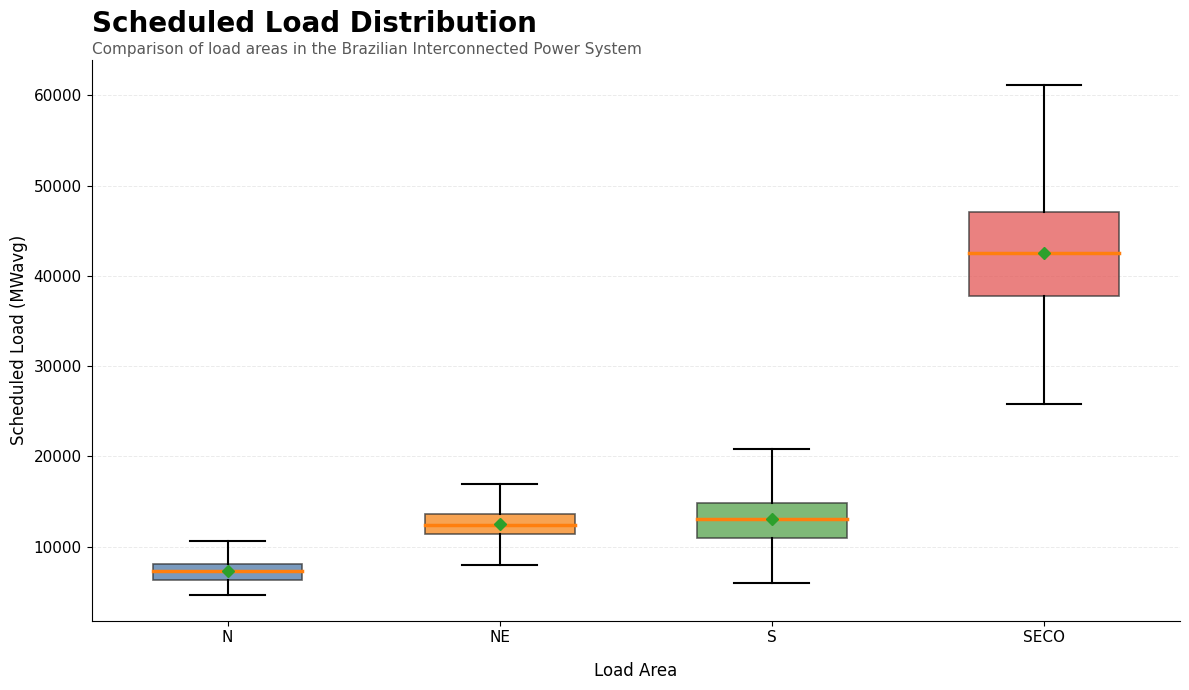

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

data = [df_refined[col].dropna() for col in cols]

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    showmeans=True,
    labels=[dict_cols[col] for col in cols],
    medianprops={
        "linewidth": 2.5,
    },
    meanprops={
        "marker": "D",
        "markersize": 6,
        "markeredgewidth": 1,
    },
    whiskerprops={
        "linewidth": 1.5,
    },
    capprops={
        "linewidth": 1.5,
    },
    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.3,
    },
)

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("#333333")
    patch.set_linewidth(1.2)

ax.set_title(
    "Scheduled Load Distribution",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Comparison of load areas in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.set_xlabel(
    "Load Area",
    fontsize=12,
    labelpad=12,
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=11,
)

plt.tight_layout()
plt.show()

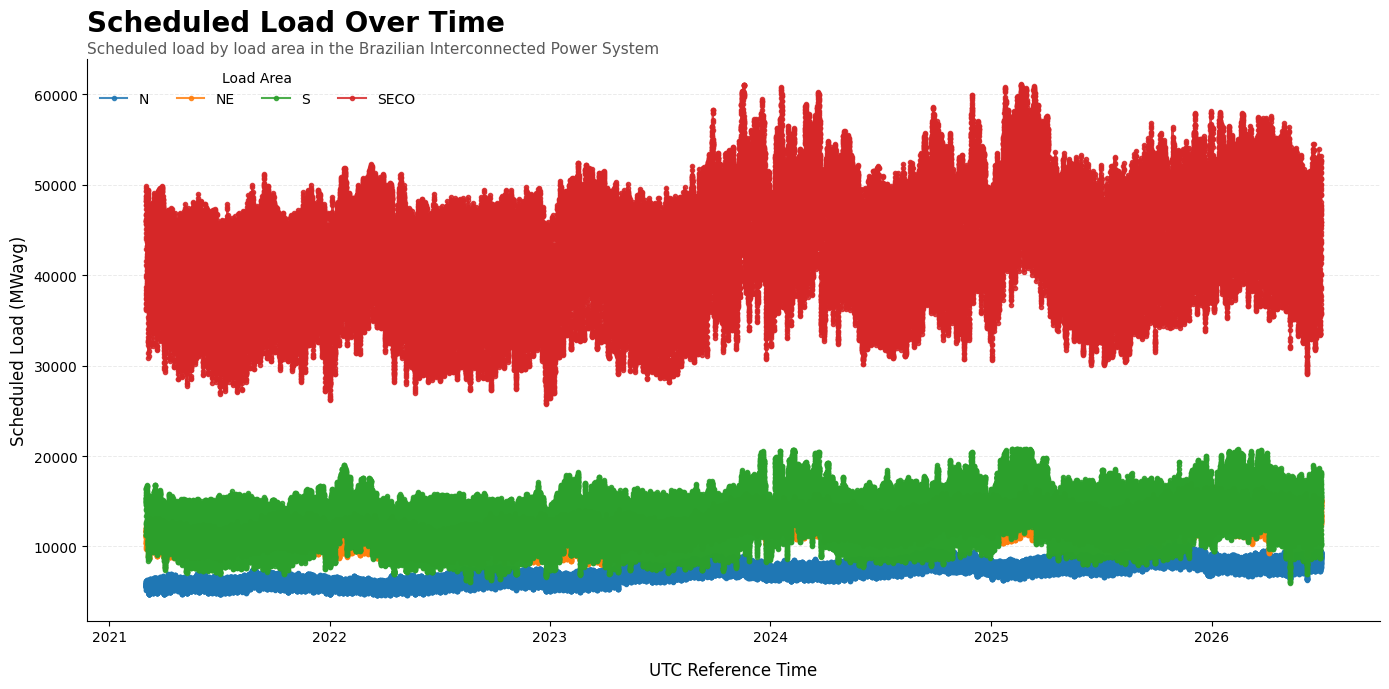

In [18]:
df_plot = df_refined.sort_values("ref_datetime")

fig, ax = plt.subplots(figsize=(14, 7))

for col in cols:
    ax.plot(
        df_plot["ref_datetime"],
        df_plot[col],
        marker="o",
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
        label=dict_cols[col],
    )

ax.set_title(
    "Scheduled Load Over Time",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Scheduled load by load area in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_xlabel(
    "UTC Reference Time",
    fontsize=12,
    labelpad=12,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Load Area",
    frameon=False,
    ncol=4,
)

plt.tight_layout()
plt.show()